# Nociones básicas de clases en Python

Para desarrollar nuestras redes neuronales vamos a usar *clases* de Python. Solo las vamos a utilizar como estructuras de datos un poco más amigables que simples tuplas. Técnicamente todo se puede hacer con listas de vectores, pero poder usar variables con nombre va a hacer que se entienda mejor.

En Python podemos declarar una clase con la palabra clave `class`, por ejemplo:
```python
class Hola:
    una_variable = 1234
```

Las clases pueden tener métodos:
```python
class Hola:
    una_variable = 1234

    def Suma(self, valor):
        return self.una_variable + valor
```
La palabra clave `self` sirve para que la función sepa a qué instancia pertenece.
Los métodos de una instancia `Hola` se pueden llamar de la manera típica:
```python
hola = Hola() # Crea una instancia de la clase Hola
hola.Suma(4321) # Devuelve 5555
```

Haz una clase (se puede llamar `Hola`) con un método `Hablar` que acepte una variable `nombre` e imprima "Hola " seguido de `nombre`. Algo que funcione asi:
```python
hola = Hola()
hola.Hablar("Guille")
# Imprime "Hola Guille"
```

In [ ]:
def Hola:
    def Hablar(self, ...)

Aunque Python es muy intuitivo en algunas cosas, a veces tiene una manera de hacer las cosas un poco inusual.

¿Qué crees que hace este código?
```python
class Hola:
    mi_lista = [1,2,3]
    mi_numero = 1

v1 = Hola()
v2 = Hola()

v1.mi_lista.append(4)
v1.mi_numero = 2

print(v2.mi_numero, v2.mi_lista)
```

In [4]:
# Pruebalo

Esto es porque ciertos tipos de variables, cuando se declaran a nivel de clase (como `mi_lista`), actúan como variables compartidas por todas las instancias (como si fuesen `static` en C++).

Siempre podemos forzar que una variable sea *local* (una independiente por cada instancia) si las declarammos con `self`:
```python
class Hola:
    def PonerNombre(self, nombre):
        self.nombre = nombre

    def Hablar(self, nombre):
        print(f"Hola {nombre}, soy {self.nombre}")

hola = Hola()
hola.PonerNombre("Euler")
hola.Hablar("Erdos")
# Hola Erdos, soy Euler
```

In [7]:
# Pruebalo

Si queremos incializar variables locales podemos utilizar el metodo especial `__init__`:
```python
class Hola:
    def __init__(self):
        self.nombre = "Euler"
        
    def PonerNombre(self, nombre):
        self.nombre = nombre

    def Hablar(self, nombre):
        print(f"Hola {nombre}, soy {self.nombre}")

hola = Hola()
hola.Hablar("Erdos") # Hola Erdos, soy Euler
hola.PonerNombre("Kovalevskaya")
hola.Hablar("Erdos") # Hola Erdos, soy Kovalevskaya
```

In [9]:
# Pruebalo

# Neuronas básicas
Vimos varias *neuronas básicas* en la clase anterior. Una (que es la que suele aparecer en la *output layer*) es
$$
x \mapsto u \cdot x + b.
$$
Aquí `u` es un vector (de la misma dimensión que `x`) y `b` es un escalar que suele denominarse `bias`.

Para las capas intermedias habíamos decidido usar la misma función pero compuesta con una *funcion de activación* (que habíamos decidido que sería `relu`):
$$
x \mapsto relu(u \cdot x + b)
$$

Vamos a programar unas clases que implementen este funcionamiento. Empezamos con la funcion `relu`:

In [10]:
import numpy as np

def relu(x):
    return np.maximum(x, 0)

Completa el código de `OutputNode` para que funcione como el primer tipo. Puede ser útil la funcion `dot` de numpy:
```python
np.dot([1,2], [3,4])
# 11
```

In [30]:
class OutputNode:
    def __init__(self):
        self.u = None
        self.bias = None

    def Compute(self, input):
        # ...
        return np.dot(input, self.u) + self.bias

El siguiente código deberia imprimir "Bien":

In [31]:
node = OutputNode()
node.u = [1,2]
node.bias = -5
if node.Compute([1,1]) == -2:
    print("Bien")
else:
    print("Mal")

Bien


Haz lo mismo para `StandardNode`, que es el segundo tipo de neurona:

In [32]:
class StandardNode:
    def __init__(self):
        self.u = None
        self.bias = None

    def Compute(self, input):
        # ...
        return relu(np.dot(input, self.u) + self.bias)

El siguiente código deberia imprimir "Bien":

In [33]:
node = StandardNode()
node.u = [1,2]
node.bias = -5
if node.Compute([1,1]) == 0:
    print("Bien")
else:
    print("Mal")

Bien


# Cómo juntar neuronas

Ahora queremos hacer una función que calcule el resultado de aplicar una neurona al resultado de otra. Y, en general, enlazar varias neuronas para hacer lo que se suele llamar una "red neuronal". Para ello vamos a hacer una clase `Network` que encapsule a la red y pueda hacer los cálculos necesarios.

Para empezar (y pensando en el futuro), nuestra red va a tener dos tipos de neuronas (`OutputNode` y `StandardNode`). El "resultado" va a ser lo que salga de los nodos de tipo `OutputNode`. Vamos a pensar en nuestra red como un grafo dirigido (sin ciclos). Con esta manera de ver las cosas las neuronas son los vértices del grafo, mientras que las aristas representan la dirección en la que la información se mueve.

Por ejemplo, supongamos que tenemos unos nodos definidos así:
```python
A = StandardNode()
A.u = [1, 2]
A.bias = 3

B = StandardNode()
B.u = [-2, -1]
B.bias = 3

C = OutputNode()
C.u = [3, -4]
C.bias = 1
```

Podemos hacer una red combinando estos nodos: el resultado de aplicar `A` y `B` a $(x,y)$ se introduce (en orden) en `C`:
$$
\operatorname{Red}(x,y) = C(A(x,y), B(x,y))
$$
(el código de la siguiente celda es solo para representar el grafo, no es parte de la clase. "No entra")

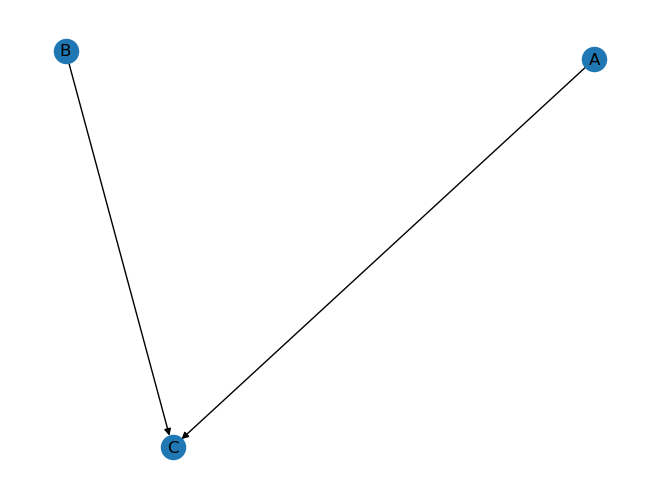

In [40]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.DiGraph()
# Adding nodes
G.add_node("A")
G.add_node("B")
G.add_node("C")

# Adding edges
G.add_edge("A", "C")
G.add_edge("B", "C")

nx.draw(G, with_labels=True, arrows=True)
plt.show()

¿Cómo podemos programar esto? Una manera es:
```python
def Red(x,y):
    return C.Compute(A.Compute(x,y), B.Compute(x,y))
```
Pero ¿qué vamos a hacer para grafos más complicados? (Y no quiero ni pensar en como calcular la derivada haciendo algo asi).

Compensa abstraer el problema un poco e implementar una clase que maneje el grafo de manera genérica.

A priori, nuestra clase debería tener al menos la lista de todos los nodos, así como las aristas que "llegan" a cada nodo. Podríamos empezar con algo así:
```python
class Network:
    def __init__(self):
        self.nodes = []
        self.inputs = {}
```
Aquí `nodes` es la lista de todos los nodos (las neuronas), e `inputs` es un diccionario que asigna a cada nodo los nodos que están unidos a este.
En pseudocódigo, el grafo de arriba podría representarse como
```python
nodes = [A, B, C]
inputs = {
    A: [],
    B: [],
    C: [A, B],
}
```

Para no repetir instancias en `inputs`, podemos dar a cada nodo un `id` único (por ejemplo, el índice que ocupa ese nodo en `nodes`):
```python
nodes = [A,B,C]
inputs = {
    0: [],
    1: [],
    2: [0, 1],
}
```

También nos vamos a simplifcar la vida diciendo cuáles son los "nodos resultado", es decir, cuáles van a formar el resultado final de aplicar la red:
```python
class Network:
    def __init__(self):
        self.nodes = []
        self.inputs = {}
        self.output_nodes = []
```
Podemos poner todo junto escribiendo algo así:

In [50]:
A = StandardNode()
A.u = [1, 2]
A.bias = 3

B = StandardNode()
B.u = [-2, -1]
B.bias = 3

C = OutputNode()
C.u = [3, -4]
C.bias = 1

class Network:
    def __init__(self):
        self.nodes = []
        self.inputs = {}
        self.output_nodes = []

nn = Network()
nn.nodes = [A, B, C]
nn.inputs = {2: [0, 1]}
nn.output_nodes = [2]

Ahora queremos calcular el resultado. Para ello vamos a ir calculando los resultados de cada neurona "en orden". ¿Que orden? Hay uno muy intuitivo que consiste en empezar por los nodos que no tienen "input"s, seguir con los vecinos de estos, luego los vecinos de los vecinos, y asi sucesivamente hasta llegar a los "output_nodes".

Este orden (que se suele llamar "orden topológico") se puede hallar usando el algoritmo Breadth First Search (BFS) empezando por los output nodes y luego dándole la vuelta. Lo que hace este algoritmo es ir añadiendo nodos en una lista en el orden en el que se descubren si no vamos al "vecino del vecino" sin terminar de añadir todos mis vecinos primero.

En codigo:
```python
topological_sort = []

queue = list(self.output_nodes)
while len(queue) != 0:
    current = queue.pop()
    topological_sort.append(current)
    for input_id in self.inputs[current]:
        queue.append(input_id)

topological_sort.reverse()
```
Ahora en `topological_sort` tenemos los nodos ordenados de forma que el resultado del nodo `topological_sort[i]` solo depende del resultado de los nodos `topological_sort[j]` con $j<i$.

Con esto ya podemos ir progamando la función que calcula el resultado final de la red:

In [55]:
class Network:
    def __init__(self):
        self.nodes = []
        self.inputs = {}
        self.output_nodes = []

    def FeedForward(self, input):
        topological_sort = []

        queue = list(self.output_nodes)
        while len(queue) != 0:
            current = queue.pop()
            topological_sort.append(current)
            for input_id in self.inputs[current]:
                queue.append(input_id)

        topological_sort.reverse()
        print(f"topsort: {topological_sort}")

        for id in topological_sort:
            print(f"Hay que calcular el resultado del nodo {id}")
            #value = self.nodes[id].Compute(current_input)

nn = Network()
nn.nodes = [A, B, C]
nn.inputs = {0: [],
             1: [],
             2: [0, 1],
            }
nn.output_nodes = [2]
nn.FeedForward([0,0])

topsort: [0, 1, 2]
Hay que calcular el resultado del nodo 0
Hay que calcular el resultado del nodo 1
Hay que calcular el resultado del nodo 2


Pero... ¿Cómo sabemos qué es `current_input`?. Esto debería ser `input` para la primera capa, pero para las siguientes se tiene que construir en función de los resultados de los nodos anteriores.

Podemos ir guardando el resultado que hemos calculado en cada nodo:
```python
    def FeedForward(self, input):
        topological_sort = []

        queue = list(self.output_nodes)
        while len(queue) != 0:
            current = queue.pop()
            topological_sort.append(current)
            for input_id in self.inputs[current]:
                queue.append(input_id)

        topological_sort.reverse()
        print(f"topsort: {topological_sort}")

        for id in topological_sort:
            print(f"Hay que calcular el resultado del nodo {id}")
            current_input = None
            if self.inputs[id]:
                current_input = # Los anteriores
            else:
                current_input = input
            value = self.nodes[id].Compute(current_input)

```

Completa la funcion para que `current_input` siempre sea el input correcto:

In [62]:
class OutputNode:
    def __init__(self):
        self.id = None
        self.u = None
        self.bias = None

        self.value = None

    def Compute(self, input):
        self.value = np.dot(input, self.u) + self.bias
        return self.value

class StandardNode:
    def __init__(self):
        self.id = None
        self.u = None
        self.bias = None

        self.value = None
        
    def Compute(self, input):
        self.value = relu(np.dot(input, self.u) + self.bias)
        return self.value

class Network:
    def __init__(self):
        self.nodes = []
        self.inputs = {}
        self.output_nodes = []

    def AddNode(self, node):
        id = len(self.nodes)
        node.id = id
        self.nodes.append(node)
        self.inputs[id] = []
        return id

    def FeedForward(self, input):
        topological_sort = []

        queue = list(self.output_nodes)
        while len(queue) != 0:
            current = queue.pop()
            topological_sort.append(current)
            for input_id in self.inputs[current]:
                queue.append(input_id)

        topological_sort.reverse()

        for id in topological_sort:
            current_input = None
            if self.inputs[id]:
                # current_input = ???
            else:
                current_input = input
            self.nodes[id].Compute(current_input)
            value = self.nodes[id].value

        # El resultado final es simplemente un vector con todos los resultados de los `output_nodes`.
        output = np.zeros(len(self.output_nodes))
        for i in range(len(self.output_nodes)):
            output[i] = self.nodes[self.output_nodes[i]].value
            
        return output

Este código debería funcionar:

In [68]:
A = StandardNode()
A.u = [1, 2]
A.bias = 3

B = StandardNode()
B.u = [-2, -1]
B.bias = 3

C = OutputNode()
C.u = [3, -4]
C.bias = 1

nn = Network()
nn.nodes = [A, B, C]
nn.inputs = {0: [],
             1: [],
             2: [0, 1],
            }
nn.output_nodes = [2]


if nn.FeedForward([0,0]) == -2:
    print("Bien")
else:
    print("Mal")

Bien


# Derivadas neuronales

Ahora que hemos aprendido a calcular el resultado de una red neuronal, nos falta hacer "la derivada" para poder ir cambiando los parámetros de cada neurona mediante el metodo del gradiente.

Para calcular estas derivadas se utiliza un metodo llamado "backpropagation".

La idea es que la regla de la cadena nos dice que, para calcular la derivada respecto de un parámetro de un nodo dado, tenemos que calcular todas las derivadas que vienen "despues" de este nodo. Por ejemplo, si nuestra red consiste en una cadena sencilla:
$$
\text{Red}(x) = A(B(C(D(x))))
$$
y $u$ es un parámetro de $D$, entonces
$$
\frac{\partial\text{Red}}{\partial u} = \frac{\partial A}{\partial x} \frac{\partial B}{\partial x} \frac{\partial C}{\partial x} \frac{\partial D}{\partial u},
$$
donde cada derivada está evaluada en los valores de la red en el nodo correspondiente.

Podemos calcular la derivada respecto de cada parámetro empezando por la derivada de los nodos de la última capa (para los cuales no necesitamos la regla de la cadena), y luego para cada capa sucesiva (en el orden BFS de antes) multiplicamos la derivada (respecto de `input`) de los antiguos por la derivada respecto al parámetro que sea. Esto es un lío, pero con la pizarra se debería entender mejor.

Visto desde el punto de vista de nuestro grafo, podemos entender el algoritmo de *backpropagation* así (en pseudocódigo):
```python
for node in BFS(output_nodes):
    multiplier_vector = # Gradiente de `node` respecto a `input`
    node.parameter_derivatives = (lo que sea) * node.multiplier
    for i in inputs[node]:
        nodes[i].multiplier = multiplier_vector[i] * node.multiplier
```

Podemos usar el mismo truco de antes e ir guardando los resultados parciales en los propios nodos.
> Esto, como muchas cosas en este notebook, es algo que nunca haríamos en código real, ya que viola todas las leyes de encapsulamiento que se le pueden ocurrir a alguien. Pero a nosotros nos sirve.

Rellenar los huecos para que el código funcione (he añadido algunas funciones útiles para no tener que construir las redes tan a mano):

In [135]:
class OutputNode:
    def __init__(self):
        self.id = None
        self.u = None
        self.bias = None

        self.value = None
        
        # Derivatives
        self.d_input = None
        self.d_u = None
        self.d_bias = None
        
        self.d_parent = 1

    def Compute(self, input):
        self.value = np.dot(input, self.u) + self.bias
        return self.value

    def ComputeDerivatives(self, input):
        self.d_input = self.u
        
        self.d_u = self.d_parent * input
        self.d_bias = self.d_parent

    def DWeights(self):
        return np.array([self.d_u, self.d_bias], dtype=object)

class StandardNode:
    def __init__(self):
        self.id = None
        self.u = None
        self.bias = None

        self.value = None
        
        # Derivatives
        self.d_input = None
        self.d_u = None
        self.d_bias = None
        self.d_parent = 1

    def Compute(self, input):
        self.value = relu(np.dot(input, self.u) + self.bias)
        return self.value

    def ComputeDerivatives(self, input):
        # Aqui falta tener en cuenta el signo del valor que hay dentro de `relu`
        self.d_input = self.u
        
        self.d_u = self.d_parent * input
        self.d_bias = self.d_parent
        
    def DWeights(self):
        return np.array([self.d_u, self.d_bias], dtype=object)

class Network:
    def __init__(self):
        self.nodes = []
        self.inputs = {}
        self.output_nodes = []

    def AddNode(self, node):
        id = len(self.nodes)
        node.id = id
        self.nodes.append(node)
        self.inputs[id] = []
        return id

    def ComputeInputFor(self, id, input):
        current_input = None
        if self.inputs[id]:
            # Falta rellenar esto
            current_input = None
        else:
            current_input = input
        return current_input

    def FeedForward(self, input):
        topological_sort = []

        queue = list(self.output_nodes)
        while len(queue) != 0:
            current = queue.pop()
            topological_sort.append(current)
            for input_id in self.inputs[current]:
                queue.append(input_id)

        topological_sort.reverse()

        for id in topological_sort:
            current_input = self.ComputeInputFor(id, input)
            self.nodes[id].Compute(current_input)
            value = self.nodes[id].value

        output = np.zeros(len(self.output_nodes))
        for i in range(len(self.output_nodes)):
            output[i] = self.nodes[self.output_nodes[i]].value
            
        return output
        
    def ComputeDerivatives(self, input):
        queue = list(self.output_nodes)
        while len(queue) != 0:
            current_id = queue.pop()
            current_node = self.nodes[current_id]
            current_input = self.ComputeInputFor(current_id, input)
            current_node.ComputeDerivatives(current_input)
            for i in range(len(self.inputs[current_id])):
                input_id = self.inputs[current_id][i]
                queue.append(input_id)
                
                input_node = self.nodes[input_id]
                input_node.d_parent = current_node.d_input[i] * current_node.d_parent
        ret = []
        for i in range(len(self.nodes)):
            ret.append(self.nodes[i].DWeights())
        return np.array(ret, dtype=object)

El siguiente código debería funcionar:

In [136]:
nn = Network()

output_node = OutputNode()
output_node.u = np.array([1.0, -2.0])
output_node.bias = 0.0
nn.AddNode(output_node)

node1 = StandardNode()
node1.u = np.array([1.0, 1.0])
node1.bias = 0.0
nn.AddNode(node1)

node2 = StandardNode()
node2.u = np.array([1.0, 1.0])
node2.bias = -1.0
nn.AddNode(node2)

nn.inputs[output_node.id] = [node1.id, node2.id]
nn.output_nodes = [output_node.id]

nn.FeedForward(np.array([1.0, 1.0]))
derivatives = nn.ComputeDerivatives(np.array([-1.0, -1.0]))
good_derivatives = np.array([
    np.array([np.array([2., 1.]), 1], dtype=object),
    np.array([np.array([0, 0]), 0], dtype=object),
    np.array([np.array([0, 0]), 0], dtype=object),
], dtype=object)
if np.linalg.norm(np.linalg.norm(derivatives-good_derivatives)) < 1e-20:
    print("Bien")
else:
    print("Mal")

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

# La función XOR
Ahora que ya tenemos un forma general de hacer redes neuronales, vamos a intentar aproximar la función XOR.

La función XOR está definida por:
```
XOR(0, 0) = 0
XOR(0, 1) = 1
XOR(1, 0) = 1
XOR(1, 1) = 0
```

Está claro que esta función no es lineal (la suma de los dos valores intermedios es $2$, así que si fuese lineal `XOR(1,1)` tendría que ser 2. Aún así, podemos aproximarla con una red neuronal de una sola capa.

Vamos a empezar haciendo unos *datos de entrenamiento*:

In [120]:
training_data = [
    [np.array([0,0]), 0],
    [np.array([0,1]), 1],
    [np.array([1,0]), 1],
    [np.array([1,1]), 0],
]

Primero, vamos a qué pasa si hacemos una red con unos parámetros muy bien elegidos:

In [137]:
nn = Network()

output_node = OutputNode()
output_node.u = np.array([1.0, -2.0])
output_node.bias = 0.0
nn.AddNode(output_node)

node1 = StandardNode()
node1.u = np.array([1.0, 1.0])
node1.bias = 0.0
nn.AddNode(node1)

node2 = StandardNode()
node2.u = np.array([1.0, 1.0])
node2.bias = -1.0
nn.AddNode(node2)

nn.inputs[output_node.id] = [node1.id, node2.id]
nn.output_nodes = [output_node.id]

for input,value in training_data:
    print(f"nn.FeedForward({input}) = {nn.FeedForward(input)} vs valor real = {value}")

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

Es decir, tenemos unos parámetros que "aproximan" la función con error cero.

El problema es que, en general, no vamos a tener tanta suerte y encontrar los parámetros buenos a la primera. Así que vamos a simular la vida real e inicializar los parámetros con valores aleatorios:

In [138]:
output_node.u = np.random.uniform(-2, 2, 2)
output_node.bias = np.random.uniform(-5,5)

node1.u = np.random.uniform(-5, 5, 2)
node1.bias = np.random.uniform(-5,5)

node2.u = np.random.uniform(-5, 5, 2)
node2.bias = np.random.uniform(-5,5)

# Ahora esto deberia ser muy distinto:
for input,value in training_data:
    computed = nn.FeedForward(input)
    print(f"NN({input}) = {computed} vs {value}. Error = {abs(value - computed).item()}")

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

Rellena la función `Update` que hay al final del código para que implemente un paso del método del gradiente correctamente. También falta el código que faltaba en las preguntas de antes.

In [131]:
class OutputNode:
    def __init__(self):
        self.id = None
        self.u = None
        self.bias = None

        self.value = None
        
        # Deriv things
        self.d_input = None
        self.d_u = None
        self.d_bias = None
        
        self.d_parent = 1

    def Compute(self, input):
        self.value = np.dot(input, self.u) + self.bias
        return self.value

    def ComputeDerivatives(self, input):
        self.d_input = self.u
        
        self.d_u = self.d_parent * input
        self.d_bias = self.d_parent

    def Weights(self):
        return np.array([self.u, self.bias], dtype=object)
        
    def DWeights(self):
        return np.array([self.d_u, self.d_bias], dtype=object)


class StandardNode:
    def __init__(self):
        self.id = None
        self.u = None
        self.bias = None

        self.value = None
        
        # Deriv things
        self.d_input = None
        self.d_u = None
        self.d_bias = None
        self.d_parent = 1

    def Weights(self):
        return np.array([self.u, self.bias], dtype=object)

    def DWeights(self):
        return np.array([self.d_u, self.d_bias], dtype=object)
    
    def Compute(self, input):
        self.value = relu(np.dot(input, self.u) + self.bias)
        return self.value
        
    def ComputeDerivatives(self, input):
        self.d_input = self.u
        
        self.d_u = self.d_parent * input
        self.d_bias = self.d_parent
        

class Network:
    def __init__(self):
        self.nodes = []
        self.inputs = {}
        self.output_nodes = []

    def AddNode(self, node):
        id = len(self.nodes)
        node.id = id
        self.nodes.append(node)
        self.inputs[id] = []
        return id

    def ComputeInputFor(self, id, input):
        current_input = None
        if self.inputs[id]:
            current_input = None
        else:
            current_input = input
        return current_input

    def FeedForward(self, input):
        topological_sort = []

        queue = list(self.output_nodes)
        while len(queue) != 0:
            current = queue.pop()
            topological_sort.append(current)
            for input_id in self.inputs[current]:
                queue.append(input_id)

        topological_sort.reverse()

        for id in topological_sort:
            current_input = self.ComputeInputFor(id, input)
            self.nodes[id].Compute(current_input)
            value = self.nodes[id].value

        output = np.zeros(len(self.output_nodes))
        for i in range(len(self.output_nodes)):
            output[i] = self.nodes[self.output_nodes[i]].value
            
        return output
        
    def ComputeDerivatives(self, input):
        queue = list(self.output_nodes)
        while len(queue) != 0:
            current_id = queue.pop()
            current_node = self.nodes[current_id]
            current_input = self.ComputeInputFor(current_id, input)
            current_node.ComputeDerivatives(current_input)
            for i in range(len(self.inputs[current_id])):
                input_id = self.inputs[current_id][i]
                queue.append(input_id)
                
                input_node = self.nodes[input_id]
                input_node.d_parent = current_node.d_input[i] * current_node.d_parent
        ret = []
        for i in range(len(self.nodes)):
            ret.append(self.nodes[i].DWeights())
        return np.array(ret, dtype=object)

    # Actualiza todos los parametros de la red neuronal dando un paso siguiendo el metodo del gradiente.
    #
    # Devuelve un par [err, norm] donde
    # * `err` es el error comparado con `training_data`.
    # * `norm` es la norma del vector de derivadas.
    def Update(self, training_data, factor=1.0):
        total_error = 0
        total_derivatives = None
        for (input, output) in training_data:
            value = self.FeedForward(input)
            total_error += (value - output)**2
            derivatives = self.ComputeDerivatives(input)
            # Rellenar esto
                
        total_error /= len(training_data)
        total_derivatives /= len(training_data)

        for i in range(len(total_derivatives)):
            node = self.nodes[i]
            node.u -= factor*total_derivatives[i][0]
            node.bias -= factor*total_derivatives[i][1]

        
        return [total_error.item(), np.linalg.norm(np.linalg.norm(total_derivatives))]

Si lo has programado bien, este código deberia funcionar. El código prueba con muchos parámetros elegidos aleatoriamente y para cuando el error es suficientemente pequeño (o hace demasiadas iteraciones)

In [140]:
nn = Network()

output_node = OutputNode()
nn.AddNode(output_node)

node1 = StandardNode()
nn.AddNode(node1)

node2 = StandardNode()
nn.AddNode(node2)

nn.inputs[output_node.id] = [node1.id, node2.id]
nn.output_nodes = [output_node.id]

err = 1
max_attempts = 1000
max_epochs = 10000
attempts = 0
while err > 1e-10 and attempts < max_attempts:
    attempts += 1
    output_node.u = np.random.uniform(-2, 2, 2)
    output_node.bias = np.random.uniform(-5,5)

    node1.u = np.random.uniform(-5, 5, 2)
    node1.bias = np.random.uniform(-5,5)

    node2.u = np.random.uniform(-5, 5, 2)
    node2.bias = np.random.uniform(-5,5)

    prev = 1
    epoch = 0
    while prev > 1e-10 and epoch < max_epochs:
        epoch += 1
        err, prev = nn.Update(training_data, 1e-1)
    print(f"Epochs = {epoch}, error = {err}")
print(f"Done. Final error = {err}.\n\n\n")
for input,value in training_data:
    computed = nn.FeedForward(input)
    print(f"NN({input}) = {computed} vs {value}. Error = {abs(value - computed).item()}")

AttributeError: 'Network' object has no attribute 'Update'